In [ ]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import myfunction as mf
from path_config import *
import os
from netCDF4 import Dataset
from scipy import stats

def get_thq_nc_data(file_path, output_path, str_colname):
    df = pd.read_csv(file_path)

    df = df[['lon', 'lat', 'year', str_colname]]


    df = df[(df['year'] >= 2000) & (df['year'] <= 2020)]


    pivot_df = df.pivot_table(index=['lon', 'lat'], columns='year', values=str_colname)


    pivot_df.reset_index(inplace=True)
    pivot_df.columns.name = None

    years = list(map(int, range(2000, 2020 + 1)))

    if 'thq' in str_colname:
        pivot_df['potentially'] = pivot_df[years].apply(lambda row: (row >= 1).sum() / 21 if (row >= 1).sum() > 0 else 0, axis=1)
        pivot_df['sum'] = pivot_df[years].apply(lambda row: (row >= 1).sum(), axis=1)
        pivot_df['avgthq'] = pivot_df[years].mean(axis=1)
    elif 'pop' in str_colname:
        pivot_df['avgpop'] = pivot_df[years].mean(axis=1)



    pivot_df.to_csv(output_path, index=False)
    print("数据已成功转换并保存到:", output_path)
    return 'okk'





def change_to_nc(path_final, path_data, data_type, str_colname='value'):
    name_new_file = f'{data_type}_{str_colname}.nc'
    df = pd.read_csv(path_data + data_type + '.csv')
    df = df[['lon', 'lat', str_colname]]
    nc_file = Dataset(path_final + name_new_file, 'w', format='NETCDF4')

    lon = np.arange(-180, 180, 1)
    lat = np.arange(-90, 90, 1)

    nc_file.createDimension('lon', len(lon))
    nc_file.createDimension('lat', len(lat))


    lon_var = nc_file.createVariable('lon', 'f4', 'lon')
    lat_var = nc_file.createVariable('lat', 'f4', 'lat')


    lon_var[:] = lon
    lat_var[:] = lat


    value_var = nc_file.createVariable(str_colname, 'f4', ('lat', 'lon'))


    value_data = np.full((len(lat), len(lon)), np.nan)
    for index, row in df.iterrows():
        if row['lon'] != -180 and row['lon'] != 180 and row['lat'] != -90 and row['lat'] != 90:

            value_data[int(row['lat'] + 90), int(row['lon'] + 180)] = row[str_colname]
    value_var[:, :] = value_data

    nc_file.close()
    return print('over')


def statistics_total_imp_pop(df_pop, df_grid, df_country, prefix=None):

    df_merged = pd.merge(df_pop, df_grid[['lon', 'lat', 'year', 'country_id']], on=['lon', 'lat', 'year'], how='left')
    df_merged = pd.merge(df_merged, df_country[['country_id', 'region']], on='country_id', how='left')
    df_merged = pd.merge(df_merged, df_country[['country_id', 'country_ename']], on='country_id', how='left')

    imp_pop_columns = [col for col in df_merged.columns if col.startswith('imp_pop_')]


    df_global_list = []
    for i, col in enumerate(imp_pop_columns):
        temp_df = df_merged.groupby('year')[col].sum().reset_index()
        temp_df['group'] = i
        temp_df.columns = ['year', 'sum_pop', 'group']
        df_global_list.append(temp_df)

    df_global = pd.concat(df_global_list, ignore_index=True)


    df_region_list = []
    for i, col in enumerate(imp_pop_columns):

        temp_df = df_merged.groupby(['region', 'year'])[col].sum().reset_index()

        temp_df = temp_df.groupby('region')[col].agg(['mean', 'median']).reset_index()
        temp_df['group'] = i
        temp_df.columns = ['region', 'avg_pop', 'median_pop', 'group']
        df_region_list.append(temp_df)

    df_region = pd.concat(df_region_list, ignore_index=True)


    df_country_list = []
    for i, col in enumerate(imp_pop_columns):
        temp_df = df_merged.groupby(['country_ename', 'year'])[col].sum().reset_index()
        temp_df = temp_df.groupby('country_ename')[col].agg(['mean', 'median']).reset_index()
        temp_df['group'] = i
        temp_df.columns = ['country_ename', 'avg_pop', 'median_pop', 'group']
        df_country_list.append(temp_df)

    df_country = pd.concat(df_country_list, ignore_index=True)


    df_global.to_csv(os.path.join(path_part4_pop, f'global_{prefix}impact_population.csv'), index=False)
    df_region.to_csv(os.path.join(path_part4_pop, f'region_{prefix}impact_population.csv'), index=False)
    df_country.to_csv(os.path.join(path_part4_pop, f'country_{prefix}impact_population.csv'), index=False)
    return print("over, files saved")

def calculate_confidence_interval(df_global, marker=None):
    """
    计算给定数据的置信区间
    :param data: 输入数据
    :param confidence: 置信水平
    :return: 置信区间 (lower_bound, upper_bound)
    """

    average_population = df_global['sum_pop'].mean()
    median_population = df_global['sum_pop'].median()


    confidence_interval = stats.norm.interval(0.95, loc=average_population, scale=stats.sem(df_global['sum_pop']))


    print(f"-------{marker}-------")
    print(f"全球影响人口的平均数: {average_population}")
    print(f"全球影响人口的中位数: {median_population}")
    print(f"全球影响人口的95%置信区间: {confidence_interval}")
    print(f"-------{marker}-------")
    return 'okk'

### thq

In [20]:
file_path = path_part4_thq + 'merged_thq_statistics.csv'
output_path = path_part4_nc + 'thq_fig_data.csv'

file_path1 = path_part4_thq + 'sw_thq_statistics.csv'
output_path1 = path_part4_nc + 'sw_thq_fig_data.csv'

file_path2 = path_part4_thq + 'lr_thq_statistics.csv'
output_path2 = path_part4_nc + 'lr_thq_fig_data.csv'

get_thq_nc_data(file_path, output_path, 'thq_50%')
get_thq_nc_data(file_path1, output_path1, 'thq_water_50%')
get_thq_nc_data(file_path2, output_path2, 'thq_fish_50%')

数据已成功转换并保存到: E:wyy/code_project/running_outcome/final_data/SPDB/part4_assess\nc\thq_fig_data.csv
数据已成功转换并保存到: E:wyy/code_project/running_outcome/final_data/SPDB/part4_assess\nc\sw_thq_fig_data.csv
数据已成功转换并保存到: E:wyy/code_project/running_outcome/final_data/SPDB/part4_assess\nc\lr_thq_fig_data.csv


'okk'

In [21]:
file_path = path_part4_thq + 'merged_sc_thq_statistics.csv'
output_path = path_part4_nc + 'thq_sc_fig_data.csv'

file_path1 = path_part4_thq + 'sw_sc_thq_statistics.csv'
output_path1 = path_part4_nc + 'sw_sc_thq_fig_data.csv'

file_path2 = path_part4_thq + 'lr_sc_thq_statistics.csv'
output_path2 = path_part4_nc + 'lr_sc_thq_fig_data.csv'

get_thq_nc_data(file_path, output_path, 'thq_50%')
get_thq_nc_data(file_path1, output_path1, 'thq_water_50%')
get_thq_nc_data(file_path2, output_path2, 'thq_fish_50%')

数据已成功转换并保存到: E:wyy/code_project/running_outcome/final_data/SPDB/part4_assess\nc\thq_sc_fig_data.csv
数据已成功转换并保存到: E:wyy/code_project/running_outcome/final_data/SPDB/part4_assess\nc\sw_sc_thq_fig_data.csv
数据已成功转换并保存到: E:wyy/code_project/running_outcome/final_data/SPDB/part4_assess\nc\lr_sc_thq_fig_data.csv


'okk'

In [22]:
file_path = path_part4_thq + 'merged_lc_thq_statistics.csv'
output_path = path_part4_nc + 'thq_lc_fig_data.csv'

file_path1 = path_part4_thq + 'sw_lc_thq_statistics.csv'
output_path1 = path_part4_nc + 'sw_lc_thq_fig_data.csv'

file_path2 = path_part4_thq + 'lr_lc_thq_statistics.csv'
output_path2 = path_part4_nc + 'lr_lc_thq_fig_data.csv'

get_thq_nc_data(file_path, output_path, 'thq_50%')
get_thq_nc_data(file_path1, output_path1, 'thq_water_50%')
get_thq_nc_data(file_path2, output_path2, 'thq_fish_50%')

数据已成功转换并保存到: E:wyy/code_project/running_outcome/final_data/SPDB/part4_assess\nc\thq_lc_fig_data.csv
数据已成功转换并保存到: E:wyy/code_project/running_outcome/final_data/SPDB/part4_assess\nc\sw_lc_thq_fig_data.csv
数据已成功转换并保存到: E:wyy/code_project/running_outcome/final_data/SPDB/part4_assess\nc\lr_lc_thq_fig_data.csv


'okk'

In [23]:
# potentially
# sum
list_data_type = ['thq_fig_data', 'lr_thq_fig_data', 'sw_thq_fig_data']
for data_type in list_data_type:
    change_to_nc(path_part4_nc, path_part4_nc, data_type, 'avgthq')

over
over
over


In [24]:

list_data_type2 = ['thq_sc_fig_data', 'lr_sc_thq_fig_data', 'sw_sc_thq_fig_data',
                  'thq_lc_fig_data', 'lr_lc_thq_fig_data', 'sw_lc_thq_fig_data']
for data_type in list_data_type2:
    change_to_nc(path_part4_nc, path_part4_nc, data_type, 'avgthq')

over
over
over
over
over
over


### pop

In [25]:
file_path3 = path_part4_pop + 'combined_pop_statistics.csv'
output_path3 = path_part4_nc + 'pop_fig_data.csv'

file_path4 =path_part4_pop + 'sw_pop_statistics.csv'
output_path4 = path_part4_nc + 'sw_pop_fig_data.csv'

file_path5 = path_part4_pop + 'lr_pop_statistics.csv'
output_path5 = path_part4_nc + 'lr_pop_fig_data.csv'

get_thq_nc_data(file_path3, output_path3, 'imp_pop_50%')
get_thq_nc_data(file_path4, output_path4, 'imp_pop_50%')
get_thq_nc_data(file_path5, output_path5, 'imp_pop_50%')

数据已成功转换并保存到: E:wyy/code_project/running_outcome/final_data/SPDB/part4_assess\nc\pop_fig_data.csv
数据已成功转换并保存到: E:wyy/code_project/running_outcome/final_data/SPDB/part4_assess\nc\sw_pop_fig_data.csv
数据已成功转换并保存到: E:wyy/code_project/running_outcome/final_data/SPDB/part4_assess\nc\lr_pop_fig_data.csv


'okk'

In [26]:
file_path3 = path_part4_pop + 'combined_sc_pop_statistics.csv'
output_path3 = path_part4_nc + 'pop_sc_fig_data.csv'

file_path4 =path_part4_pop + 'sw_sc_pop_statistics.csv'
output_path4 = path_part4_nc + 'sw_sc_pop_fig_data.csv'

file_path5 = path_part4_pop + 'lr_sc_pop_statistics.csv'
output_path5 = path_part4_nc + 'lr_sc_pop_fig_data.csv'

get_thq_nc_data(file_path3, output_path3, 'imp_pop_50%')
get_thq_nc_data(file_path4, output_path4, 'imp_pop_50%')
get_thq_nc_data(file_path5, output_path5, 'imp_pop_50%')

数据已成功转换并保存到: E:wyy/code_project/running_outcome/final_data/SPDB/part4_assess\nc\pop_sc_fig_data.csv
数据已成功转换并保存到: E:wyy/code_project/running_outcome/final_data/SPDB/part4_assess\nc\sw_sc_pop_fig_data.csv
数据已成功转换并保存到: E:wyy/code_project/running_outcome/final_data/SPDB/part4_assess\nc\lr_sc_pop_fig_data.csv


'okk'

In [27]:
file_path3 = path_part4_pop + 'combined_lc_pop_statistics.csv'
output_path3 = path_part4_nc + 'pop_lc_fig_data.csv'

file_path4 =path_part4_pop + 'sw_lc_pop_statistics.csv'
output_path4 = path_part4_nc + 'sw_lc_pop_fig_data.csv'

file_path5 = path_part4_pop + 'lr_lc_pop_statistics.csv'
output_path5 = path_part4_nc + 'lr_lc_pop_fig_data.csv'

get_thq_nc_data(file_path3, output_path3, 'imp_pop_50%')
get_thq_nc_data(file_path4, output_path4, 'imp_pop_50%')
get_thq_nc_data(file_path5, output_path5, 'imp_pop_50%')

数据已成功转换并保存到: E:wyy/code_project/running_outcome/final_data/SPDB/part4_assess\nc\pop_lc_fig_data.csv
数据已成功转换并保存到: E:wyy/code_project/running_outcome/final_data/SPDB/part4_assess\nc\sw_lc_pop_fig_data.csv
数据已成功转换并保存到: E:wyy/code_project/running_outcome/final_data/SPDB/part4_assess\nc\lr_lc_pop_fig_data.csv


'okk'

In [28]:
# potentially
# sum
list_data_type = ['pop_sc_fig_data', 'sw_sc_pop_fig_data', 'lr_sc_pop_fig_data',
                  'pop_lc_fig_data', 'sw_lc_pop_fig_data', 'lr_lc_pop_fig_data']
for data_type in list_data_type:
    change_to_nc(path_part4_nc, path_part4_nc, data_type, 'avgpop')


over
over
over
over
over
over


In [29]:
list_data_type = ['pop_fig_data', 'lr_pop_fig_data', 'sw_pop_fig_data']
for data_type in list_data_type:
    change_to_nc(path_part4_nc, path_part4_nc, data_type, 'avgpop')


over
over
over


### draw

In [ ]:


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter




def draw_bar_pop(df_data, prefix1, prefix2, title, min_data=1e4, max_data=3e9):
    sns.set_palette("deep")


    plt.figure(figsize=(6, 3))
    custom_params = {"axes.spines.right": False, "axes.spines.top": False}
    sns.set_theme(style="ticks", rc=custom_params)

    region_stats = df_data.groupby(prefix1).agg({'avg_pop': ['mean', 'min', 'max']})
    region_stats.columns = ['mean', 'min', 'max']
    region_stats = region_stats.sort_values('mean', ascending=True)


    region_stats['error_lower'] = region_stats['mean'] - region_stats['min']
    region_stats['error_upper'] = region_stats['max'] - region_stats['mean']


    bars = plt.barh(region_stats.index, region_stats['mean'], 
                    xerr=[region_stats['error_lower'], region_stats['error_upper']], 
                    capsize=5)






    plt.title(title, fontsize=16)
    plt.ylabel('', fontsize=12)
    plt.xlabel('', fontsize=12)
    plt.tight_layout()
    plt.xscale('log')
    plt.xlim(min_data, max_data)

    plt.savefig(os.path.join(path_part4_fig, f'{prefix1}_{prefix2}impact_population_bar.svg'), dpi=300)
    plt.show()
    plt.close()


def draw_line_pop(df_data, prefix, title, min_data=1e6, max_data=3e9):
    plt.figure(figsize=(6, 4))

    global_stats = df_data.groupby('year').agg({'sum_pop': ['mean', 'std']})
    global_stats.columns = ['mean', 'std']


    ax = plt.errorbar(global_stats.index, global_stats['mean'], yerr=global_stats['std'], fmt='-o', capsize=5)

    plt.title(title, fontsize=16)
    plt.xlabel('', fontsize=12)
    plt.ylabel('', fontsize=12)
    plt.ticklabel_format(style='plain', axis='y')  # 避免科学记数法
    plt.yscale('log')
    plt.ylim(min_data, max_data)
    plt.tight_layout()
    plt.yticks(fontsize=14)
    plt.xticks(fontsize=14, rotation=90)




    plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x)}'))
    plt.subplots_adjust(left=0.1,right=0.95,bottom=0.20,top=0.9)
    plt.savefig(os.path.join(path_part4_fig, f'global_{prefix}impact_population_line.svg'), dpi=300)
    plt.show()
    plt.close()

In [ ]:



df_grid = pd.read_csv(path_part4_grid + 'new_grid_year.csv')
df_country = pd.read_csv(path_part4_hi + 'country.csv')

df_pop = pd.read_csv(path_part4_pop + 'combined_imp_pop.csv')
df_pop_lc = pd.read_csv(path_part4_pop + 'combined_lc_imp_pop.csv')
df_pop_sc = pd.read_csv(path_part4_pop + 'combined_sc_imp_pop.csv')

statistics_total_imp_pop(df_pop, df_grid, df_country, prefix='')
statistics_total_imp_pop(df_pop_lc, df_grid, df_country, prefix='lc_')
statistics_total_imp_pop(df_pop_sc, df_grid, df_country, prefix='sc_')

over, files saved
over, files saved
over, files saved


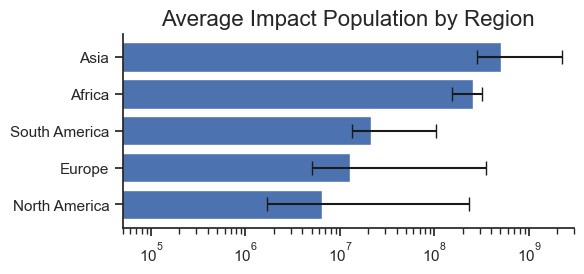

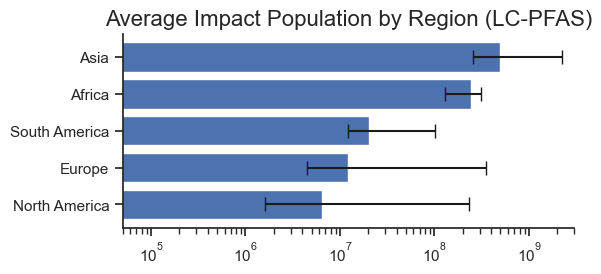

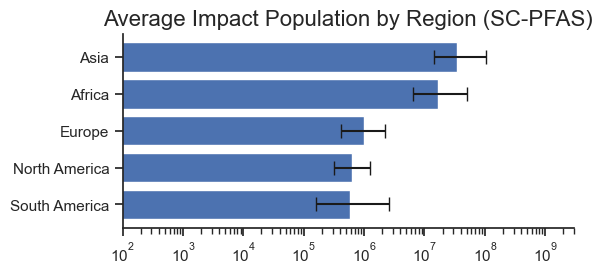

In [32]:


df_region = pd.read_csv(path_part4_pop + 'region_impact_population.csv')
df_region_lc = pd.read_csv(path_part4_pop + 'region_lc_impact_population.csv')
df_region_sc = pd.read_csv(path_part4_pop + 'region_sc_impact_population.csv')

def plot_top_avg_pop(df, n):
    avg_pop_stats = df.groupby('region')['avg_pop'].mean().reset_index()
    top_countries = avg_pop_stats.sort_values(by='avg_pop', ascending=False).head(n)['region']
    filtered_df = df[df['region'].isin(top_countries)]
    return filtered_df

n=5

top_n_df_region = plot_top_avg_pop(df_region, n)
top_n_df_region_lc = plot_top_avg_pop(df_region_lc, n)
top_n_df_region_sc = plot_top_avg_pop(df_region_sc, n)

draw_bar_pop(top_n_df_region, 'region', '', 'Average Impact Population by Region', min_data=5e4)
draw_bar_pop(top_n_df_region_lc, 'region', 'lc_', 'Average Impact Population by Region (LC-PFAS)', min_data=5e4)
draw_bar_pop(top_n_df_region_sc, 'region', 'sc_', 'Average Impact Population by Region (SC-PFAS)', min_data=1e2)


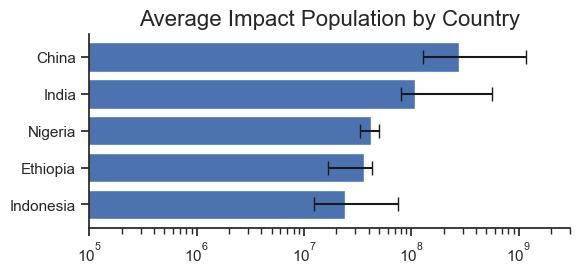

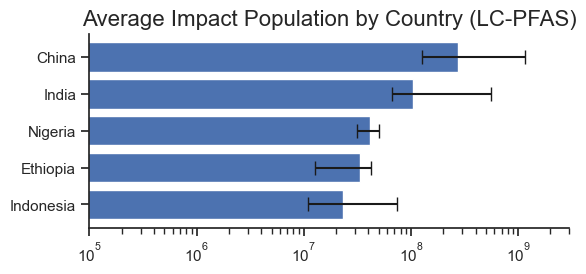

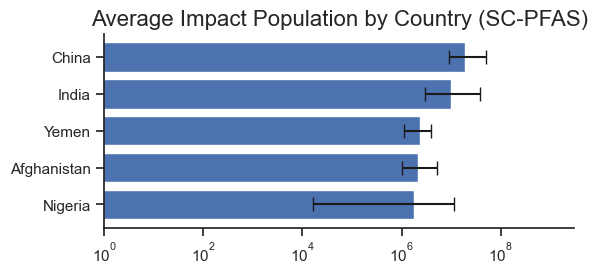

In [33]:
df_country = pd.read_csv(path_part4_pop + 'country_impact_population.csv')
df_country_lc = pd.read_csv(path_part4_pop + 'country_lc_impact_population.csv')
df_country_sc = pd.read_csv(path_part4_pop + 'country_sc_impact_population.csv')



def plot_top_avg_pop(df, n):
    avg_pop_stats = df.groupby('country_ename')['avg_pop'].mean().reset_index()
    top_countries = avg_pop_stats.sort_values(by='avg_pop', ascending=False).head(n)['country_ename']
    filtered_df = df[df['country_ename'].isin(top_countries)]
    return filtered_df

n=5
top_n_df_country = plot_top_avg_pop(df_country, n)
draw_bar_pop(top_n_df_country, 'country_ename', '', 'Average Impact Population by Country', min_data=1e5)

top_n_df_country_lc = plot_top_avg_pop(df_country_lc, n)
draw_bar_pop(top_n_df_country_lc, 'country_ename', 'lc_', 'Average Impact Population by Country (LC-PFAS)', min_data=1e5)

top_n_df_country_sc = plot_top_avg_pop(df_country_sc, n)
draw_bar_pop(top_n_df_country_sc, 'country_ename', 'sc_', 'Average Impact Population by Country (SC-PFAS)', min_data=1e0)


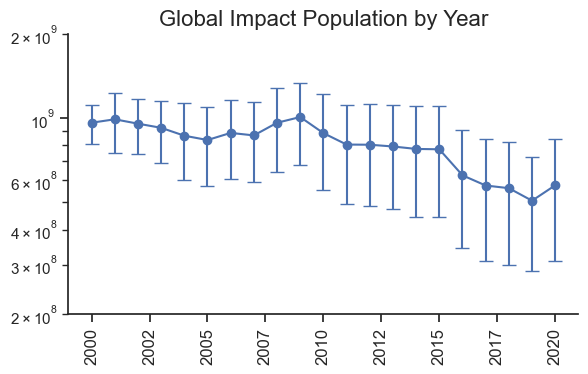

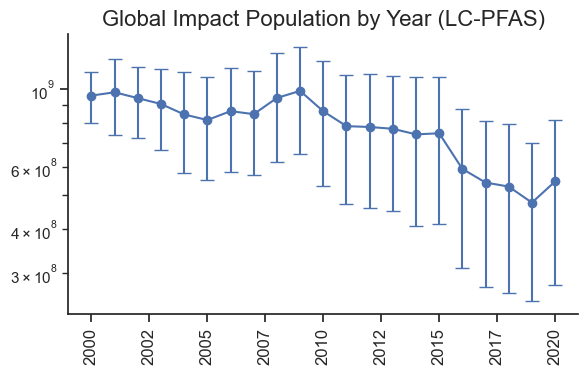

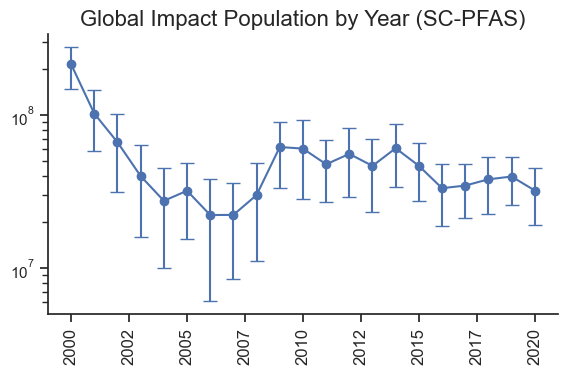

In [ ]:

df_global = pd.read_csv(path_part4_pop + 'global_impact_population.csv')
df_global_lc = pd.read_csv(path_part4_pop + 'global_lc_impact_population.csv')
df_global_sc = pd.read_csv(path_part4_pop + 'global_sc_impact_population.csv')



draw_line_pop(df_global, '', 'Global Impact Population by Year', min_data=2e8, max_data=2e9)
draw_line_pop(df_global_lc, 'lc_', 'Global Impact Population by Year (LC-PFAS)', min_data=None, max_data=None)
draw_line_pop(df_global_sc, 'sc_', 'Global Impact Population by Year (SC-PFAS)', min_data=None, max_data=None)

In [ ]:
def draw_linear_regression(df_data, prefix, title, min_data=1e6, max_data=3e9):
    plt.figure(figsize=(6, 4))

    global_stats = df_data.groupby('year').agg({'sum_pop': ['mean', 'std']})
    global_stats.columns = ['mean', 'std']


    ax = plt.errorbar(global_stats.index, global_stats['mean'], yerr=global_stats['std'], fmt='-o', capsize=5)


    years = global_stats.index
    mean_values = global_stats['mean']
    slope, intercept, r_value, p_value, std_err = stats.linregress(years, mean_values)


    plt.plot(years, slope * years + intercept, color='red', linestyle='--', label='Linear Regression')


    print(f"Linear regression p-value for {title}: {p_value:.3e}")


    equation = f'y = {slope:.2e}x + {intercept:.2e}'


    plt.title(f'{title}', fontsize=16)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Impact Population', fontsize=12)
    plt.ticklabel_format(style='plain', axis='y')  # 避免科学记数法
    plt.yscale('log')
    plt.ylim(min_data, max_data)
    plt.tight_layout()
    plt.xticks(fontsize=12, rotation=90)


    plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x)}'))
    plt.subplots_adjust(left=0.1, right=0.95, bottom=0.20, top=0.9)


    plt.text(0.75, 0.95, f'{equation}\np-value = {p_value:.3e}', transform=plt.gca().transAxes,
             fontsize=12, color='black', verticalalignment='top', horizontalalignment='center', 
             bbox=dict(facecolor='white', edgecolor='none', alpha=0.8))


    plt.legend(loc='upper left')


    plt.savefig(os.path.join(path_part4_fig, f'global_{prefix}impact_population_linear_regression.svg'), dpi=300)
    plt.show()
    plt.close()


Linear regression p-value for Global Impact Population by Year: 1.565e-07


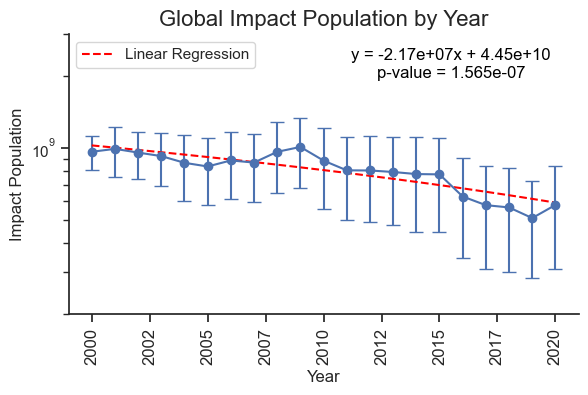

Linear regression p-value for Global Impact Population by Year (LC-PFAS): 8.460e-08


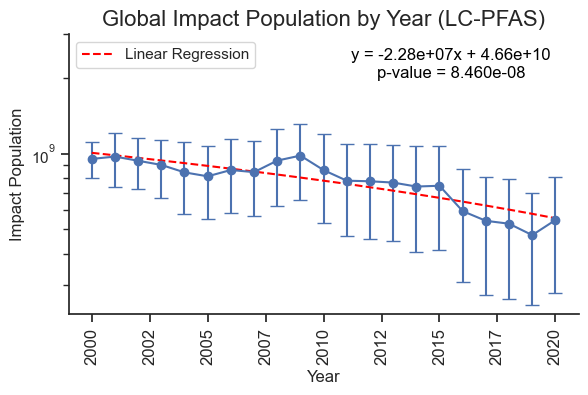

Linear regression p-value for Global Impact Population by Year (SC-PFAS): 4.383e-02


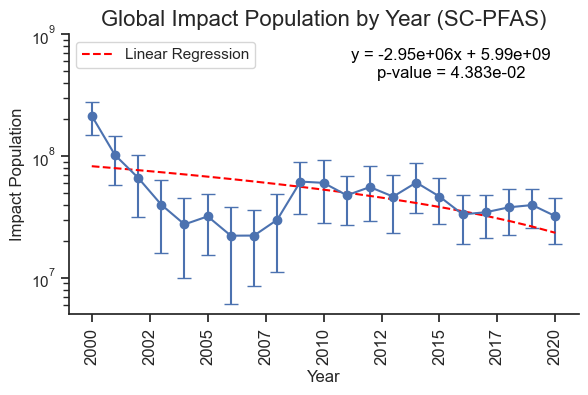

In [ ]:
df_global = pd.read_csv(path_part4_pop + 'global_impact_population.csv')
df_global_lc = pd.read_csv(path_part4_pop + 'global_lc_impact_population.csv')
df_global_sc = pd.read_csv(path_part4_pop + 'global_sc_impact_population.csv')

draw_linear_regression(df_global, '', 'Global Impact Population by Year', min_data=2e8, max_data=3e9)
draw_linear_regression(df_global_lc, 'lc_', 'Global Impact Population by Year (LC-PFAS)', min_data=None, max_data=3e9)
draw_linear_regression(df_global_sc, 'sc_', 'Global Impact Population by Year (SC-PFAS)', min_data=None, max_data=1e9)

### 看看区间

In [ ]:
import pandas as pd
import numpy as np



df_global = pd.read_csv(path_part4_pop + 'global_impact_population.csv')
calculate_confidence_interval(df_global, 'PFAS')
df_global_lc = pd.read_csv(path_part4_pop + 'global_lc_impact_population.csv')
calculate_confidence_interval(df_global_lc, 'LC-PFAS')
df_global_sc = pd.read_csv(path_part4_pop + 'global_sc_impact_population.csv')
calculate_confidence_interval(df_global_sc, 'SC-PFAS')





-------PFAS-------
全球影响人口的平均数: 806259905.7344733
全球影响人口的中位数: 761147665.8885832
全球影响人口的95%置信区间: (801968037.7248818, 810551773.7440649)
-------PFAS-------
-------LC-PFAS-------
全球影响人口的平均数: 782462411.4645821
全球影响人口的中位数: 740793211.6364118
全球影响人口的95%置信区间: (778107222.9195755, 786817600.0095887)
-------LC-PFAS-------
-------SC-PFAS-------
全球影响人口的平均数: 52982612.25071251
全球影响人口的中位数: 38239042.89373142
全球影响人口的95%置信区间: (52329244.18278972, 53635980.31863529)
-------SC-PFAS-------


'okk'

In [ ]:
df_grid_re = pd.read_csv(path_parts_data + 'grid_re.csv')
df_sw = pd.read_csv(path_part4_nc + 'sw_thq_fig_data.csv')
df_sw_s = df_sw[['lon', 'lat', 'avgthq']].copy()

df_lr = pd.read_csv(path_part4_nc + 'lr_thq_fig_data.csv')
df_lr_s = df_lr[['lon', 'lat', 'avgthq']].copy()

lr_merged_df = pd.merge(df_lr_s, df_grid_re, on=['lon', 'lat'], how='left')
sw_merged_df = pd.merge(df_sw_s, df_grid_re, on=['lon', 'lat'], how='left')


lr_count = lr_merged_df['avgthq'].gt(1).sum()
sw_count = sw_merged_df['avgthq'].gt(1).sum()
total_count_lr = len(lr_merged_df)
total_count_sw = len(sw_merged_df)
print(f"LR THQ > 1: {lr_count} ({lr_count / total_count_lr:.2%})")
print(f"SW THQ > 1: {sw_count} ({sw_count / total_count_sw:.2%})")


LR THQ > 1: 7 (0.04%)
SW THQ > 1: 12437 (69.64%)
